In [1]:
# CELLULE 1: IMPORT DES BIBLIOTHÈQUES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


In [2]:
# CELLULE 2: CHARGEMENT ET PRÉPARATION
dataset = pd.read_csv("../data/processed/dataset_analytique.csv")
trc = pd.read_csv("../data/processed/sinistre_trc_enrichi.csv")

print("📊 Données chargées")
print(f"Auto: {dataset.shape} | Chantier: {trc.shape}")

📊 Données chargées
Auto: (410, 46) | Chantier: (166, 24)


In [3]:
# CELLULE 3: SÉLECTION DES FEATURES POUR CLUSTERING AUTO
print("="*50)
print("PRÉPARATION POUR CLUSTERING - SINISTRES AUTO")
print("="*50)

# Sélection des features pertinentes pour la segmentation
features_auto = []

# Features numériques disponibles
numeric_cols = ['cout_total_fcfa', 'delai_reglement_jours', 'delai_declaration_jours', 
                'franchise_fcfa', 'montant_indemnise_fcfa']

if 'age_vehicule_ans_sinistre' in dataset.columns:
    features_auto.append('age_vehicule_ans_sinistre')
if 'conducteur_anciennete_ans' in dataset.columns:
    features_auto.append('conducteur_anciennete_ans')
if 'km_parcourus_estimes' in dataset.columns:
    features_auto.append('km_parcourus_estimes')

features_auto.extend(numeric_cols)

print(f"📋 Features sélectionnées: {features_auto}")

# Nettoyage des données
df_auto_cluster = dataset[features_auto].dropna()
print(f"✅ Après nettoyage: {len(df_auto_cluster)} sinistres")

df_auto_cluster.head()

PRÉPARATION POUR CLUSTERING - SINISTRES AUTO
📋 Features sélectionnées: ['age_vehicule_ans_sinistre', 'conducteur_anciennete_ans', 'km_parcourus_estimes', 'cout_total_fcfa', 'delai_reglement_jours', 'delai_declaration_jours', 'franchise_fcfa', 'montant_indemnise_fcfa']
✅ Après nettoyage: 410 sinistres


,age_vehicule_ans_sinistre,conducteur_anciennete_ans,km_parcourus_estimes,cout_total_fcfa,delai_reglement_jours,delai_declaration_jours,franchise_fcfa,montant_indemnise_fcfa
0,13,17,504000,1440000.0,119.0,7,339000,1101000.0
1,10,19,250000,114000.0,0.0,5,114000,0.0
2,9,10,295000,270000.0,0.0,5,270000,0.0
3,4,5,148000,5172000.0,44.0,2,321000,4851000.0
4,2,17,80000,453000.0,87.0,9,243000,210000.0


In [4]:
# CELLULE 4: STANDARDISATION DES DONNÉES AUTO
print("="*50)
print("STANDARDISATION")
print("="*50)

# Standardisation
scaler = StandardScaler()
X_auto_scaled = scaler.fit_transform(df_auto_cluster)

# Vérification
print(f"Shape après standardisation: {X_auto_scaled.shape}")
print(f"Moyenne: {X_auto_scaled.mean():.2f}")
print(f"Écart-type: {X_auto_scaled.std():.2f}")

STANDARDISATION
Shape après standardisation: (410, 8)
Moyenne: -0.00
Écart-type: 1.00


RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS


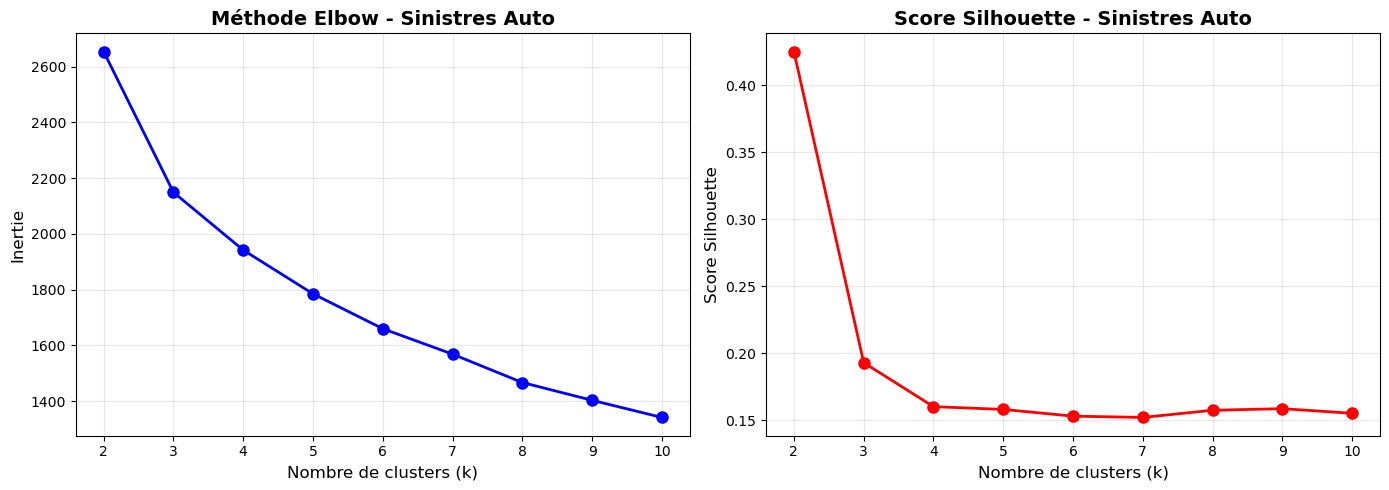


📊 Meilleur score Silhouette: k=2 avec score=0.425


In [5]:
# CELLULE 5: DÉTERMINATION DU NOMBRE OPTIMAL DE CLUSTERS (AUTO)
print("="*50)
print("RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS")
print("="*50)

# Méthode Elbow
inerties = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_auto_scaled)
    inerties.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_auto_scaled, kmeans.labels_))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inerties, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertie', fontsize=12)
axes[0].set_title('Méthode Elbow - Sinistres Auto', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Score Silhouette', fontsize=12)
axes[1].set_title('Score Silhouette - Sinistres Auto', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Meilleur score Silhouette: k={K_range[np.argmax(silhouette_scores)]} avec score={max(silhouette_scores):.3f}")

In [6]:
# CELLULE 6: APPLICATION DU CLUSTERING (AUTO)
print("="*50)
print("APPLICATION DU CLUSTERING")
print("="*50)

# Choix de k=4 (ajuster selon les résultats)
k_optimal = 4
kmeans_auto = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters_auto = kmeans_auto.fit_predict(X_auto_scaled)

# Ajout des clusters au DataFrame
df_auto_cluster['cluster'] = clusters_auto

print(f"✅ {k_optimal} clusters créés")
print("\n📊 Distribution des clusters:")
print(df_auto_cluster['cluster'].value_counts().sort_index())

APPLICATION DU CLUSTERING
✅ 4 clusters créés

📊 Distribution des clusters:
cluster
0    141
1    119
2    125
3     25
Name: count, dtype: int64


PROFILAGE DES CLUSTERS


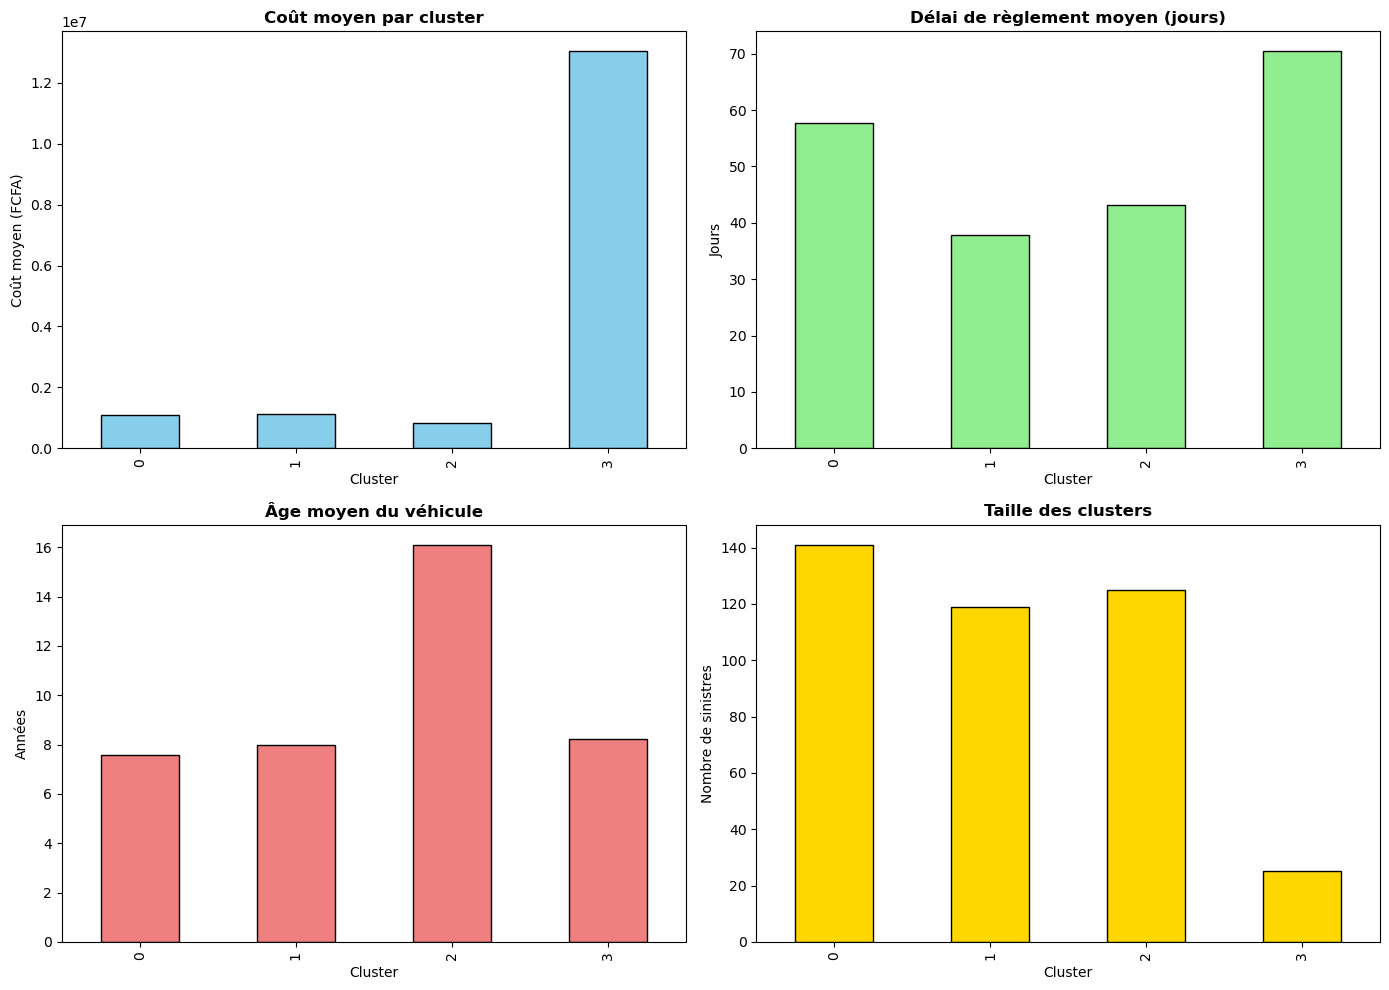

In [7]:
# CELLULE 7: PROFILAGE DES CLUSTERS (AUTO)
print("="*50)
print("PROFILAGE DES CLUSTERS")
print("="*50)

# Statistiques par cluster
cluster_stats = df_auto_cluster.groupby('cluster')[features_auto].agg(['mean', 'median', 'count'])
cluster_stats

# Visualisation des profils
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Coût total par cluster
cluster_stats['cout_total_fcfa']['mean'].plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Coût moyen par cluster', fontweight='bold')
axes[0,0].set_ylabel('Coût moyen (FCFA)')
axes[0,0].set_xlabel('Cluster')

# 2. Délai de règlement par cluster
cluster_stats['delai_reglement_jours']['mean'].plot(kind='bar', ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Délai de règlement moyen (jours)', fontweight='bold')
axes[0,1].set_ylabel('Jours')
axes[0,1].set_xlabel('Cluster')

# 3. Âge du véhicule par cluster (si disponible)
if 'age_vehicule_ans_sinistre' in features_auto:
    cluster_stats['age_vehicule_ans_sinistre']['mean'].plot(kind='bar', ax=axes[1,0], color='lightcoral', edgecolor='black')
    axes[1,0].set_title('Âge moyen du véhicule', fontweight='bold')
    axes[1,0].set_ylabel('Années')
    axes[1,0].set_xlabel('Cluster')

# 4. Taille des clusters
cluster_counts = df_auto_cluster['cluster'].value_counts().sort_index()
cluster_counts.plot(kind='bar', ax=axes[1,1], color='gold', edgecolor='black')
axes[1,1].set_title('Taille des clusters', fontweight='bold')
axes[1,1].set_ylabel('Nombre de sinistres')
axes[1,1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

In [8]:
# CELLULE 8: INTERPRÉTATION DES CLUSTERS (AUTO)
print("="*50)
print("INTERPRÉTATION DES CLUSTERS")
print("="*50)

for cluster in range(k_optimal):
    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster} ({cluster_counts[cluster]} sinistres)")
    print(f"{'='*40}")
    
    cluster_data = df_auto_cluster[df_auto_cluster['cluster'] == cluster]
    
    # Caractéristiques principales
    cout_moyen = cluster_data['cout_total_fcfa'].mean()
    delai_moyen = cluster_data['delai_reglement_jours'].mean()
    
    print(f"💰 Coût moyen: {cout_moyen:,.0f} FCFA")
    print(f"⏱️ Délai règlement: {delai_moyen:.1f} jours")
    
    if 'age_vehicule_ans_sinistre' in features_auto:
        age_moyen = cluster_data['age_vehicule_ans_sinistre'].mean()
        print(f"🚗 Âge véhicule: {age_moyen:.1f} ans")
    
    if 'conducteur_anciennete_ans' in features_auto:
        anciennete = cluster_data['conducteur_anciennete_ans'].mean()
        print(f"👤 Ancienneté conducteur: {anciennete:.1f} ans")
    
    # Profil du cluster
    print("\n📋 PROFIL:")
    if cout_moyen > df_auto_cluster['cout_total_fcfa'].mean():
        print("   • Sinistres à COÛT ÉLEVÉ")
    else:
        print("   • Sinistres à COÛT MODÉRÉ")
    
    if delai_moyen > df_auto_cluster['delai_reglement_jours'].mean():
        print("   • Délais de règlement LONGS")
    else:
        print("   • Délais de règlement RAPIDES")
    
    if 'age_vehicule_ans_sinistre' in features_auto:
        if age_moyen > df_auto_cluster['age_vehicule_ans_sinistre'].mean():
            print("   • Véhicules ANCIENS")
        else:
            print("   • Véhicules RÉCENTS")

INTERPRÉTATION DES CLUSTERS

CLUSTER 0 (141 sinistres)
💰 Coût moyen: 1,090,191 FCFA
⏱️ Délai règlement: 57.8 jours
🚗 Âge véhicule: 7.6 ans
👤 Ancienneté conducteur: 12.4 ans

📋 PROFIL:
   • Sinistres à COÛT MODÉRÉ
   • Délais de règlement LONGS
   • Véhicules RÉCENTS

CLUSTER 1 (119 sinistres)
💰 Coût moyen: 1,139,992 FCFA
⏱️ Délai règlement: 37.8 jours
🚗 Âge véhicule: 8.0 ans
👤 Ancienneté conducteur: 10.6 ans

📋 PROFIL:
   • Sinistres à COÛT MODÉRÉ
   • Délais de règlement RAPIDES
   • Véhicules RÉCENTS

CLUSTER 2 (125 sinistres)
💰 Coût moyen: 817,632 FCFA
⏱️ Délai règlement: 43.2 jours
🚗 Âge véhicule: 16.1 ans
👤 Ancienneté conducteur: 11.7 ans

📋 PROFIL:
   • Sinistres à COÛT MODÉRÉ
   • Délais de règlement RAPIDES
   • Véhicules ANCIENS

CLUSTER 3 (25 sinistres)
💰 Coût moyen: 13,032,600 FCFA
⏱️ Délai règlement: 70.4 jours
🚗 Âge véhicule: 8.2 ans
👤 Ancienneté conducteur: 12.9 ans

📋 PROFIL:
   • Sinistres à COÛT ÉLEVÉ
   • Délais de règlement LONGS
   • Véhicules RÉCENTS


VISUALISATION AVEC PCA


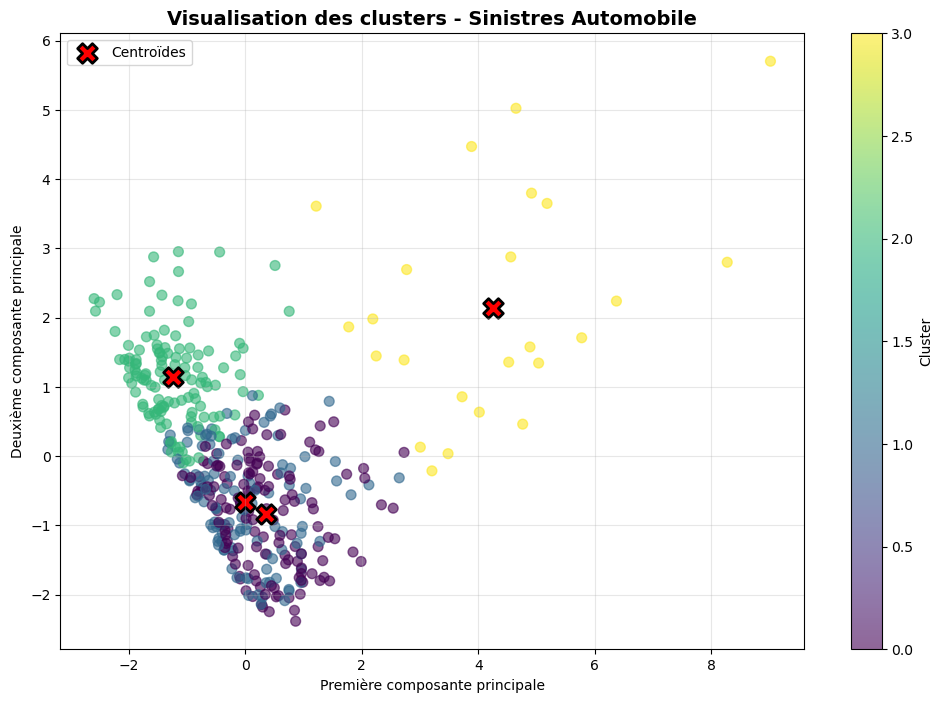


📊 Variance expliquée par les 2 composantes: 49.5%


In [17]:
# CELLULE 9: VISUALISATION 2D DES CLUSTERS (PCA)
print("="*50)
print("VISUALISATION AVEC PCA")
print("="*50)

# Réduction de dimension
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_auto_scaled)

# Visualisation
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_auto, cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualisation des clusters - Sinistres Automobile', fontsize=14, fontweight='bold')
plt.xlabel('Première composante principale')
plt.ylabel('Deuxième composante principale')
plt.grid(True, alpha=0.3)

# Ajout des centroïdes
centroids_pca = pca.transform(kmeans_auto.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroïdes')
plt.legend()
plt.show()

print(f"\n📊 Variance expliquée par les 2 composantes: {pca.explained_variance_ratio_.sum():.1%}")

CLUSTERING - SINISTRES CHANTIER
📋 Features sélectionnées: ['cout_total_fcfa', 'delai_reglement_jours', 'delai_declaration_jours', 'franchise_fcfa', 'montant_indemnise_fcfa']
✅ Après nettoyage: 166 sinistres


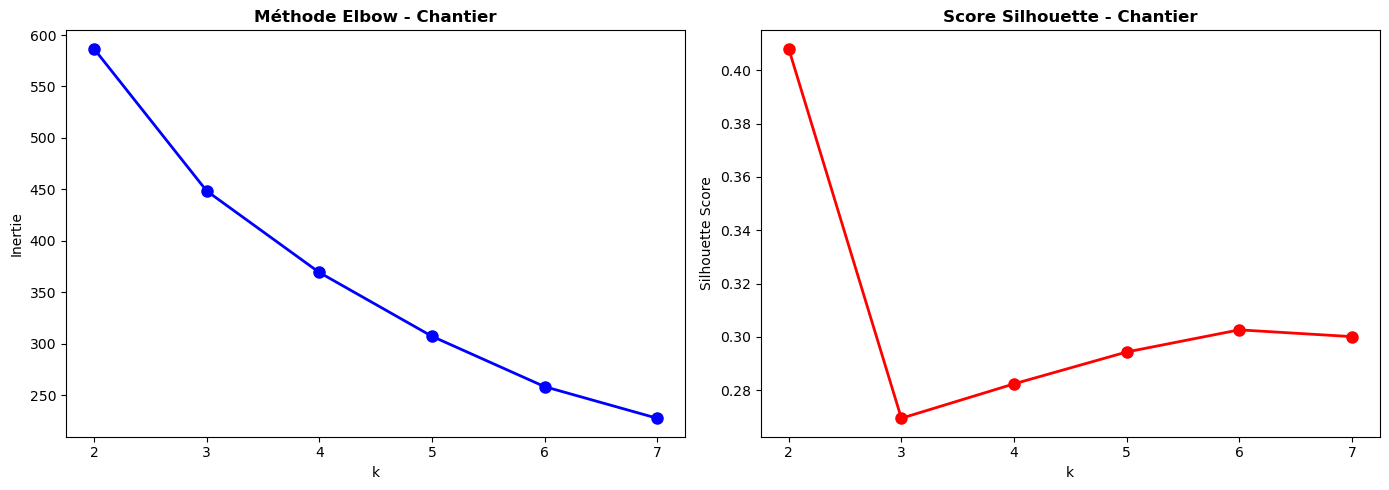

In [ ]:
# CELLULE 10: CLUSTERING POUR SINISTRES CHANTIER
print("="*50)
print("CLUSTERING - SINISTRES CHANTIER")
print("="*50)

# Sélection des features pour chantier
features_chantier = ['cout_total_fcfa', 'delai_reglement_jours', 'delai_declaration_jours', 
                     'franchise_fcfa', 'montant_indemnise_fcfa']

# Nettoyage
df_chantier_cluster = trc[features_chantier].dropna()
print(f"📋 Features sélectionnées: {features_chantier}")
print(f"✅ Après nettoyage: {len(df_chantier_cluster)} sinistres")

# Standardisation
scaler_chantier = StandardScaler()
X_chantier_scaled = scaler_chantier.fit_transform(df_chantier_cluster)

# Détermination du k optimal
inerties_chantier = []
silhouette_chantier = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_chantier_scaled)
    inerties_chantier.append(kmeans.inertia_)
    silhouette_chantier.append(silhouette_score(X_chantier_scaled, kmeans.labels_))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inerties_chantier, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Méthode Elbow - Chantier', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')

axes[1].plot(K_range, silhouette_chantier, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Score Silhouette - Chantier', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Application du clustering
k_chantier = 3
kmeans_chantier = KMeans(n_clusters=k_chantier, random_state=42, n_init=10)
clusters_chantier = kmeans_chantier.fit_predict(X_chantier_scaled)
df_chantier_cluster['cluster'] = clusters_chantier

print(f"\n✅ {k_chantier} clusters créés")
print("\nDistribution des clusters:")
print(df_chantier_cluster['cluster'].value_counts().sort_index())